<a href="https://colab.research.google.com/github/Ghalaahmed/ImageProcessing/blob/main/Lab4/Lab4_Intensity_Transformations_%26_Filtering_Spatial_Domain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


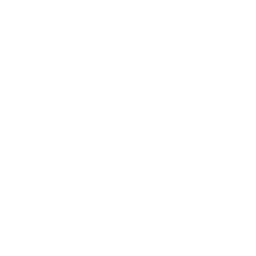

Threshold value: 50


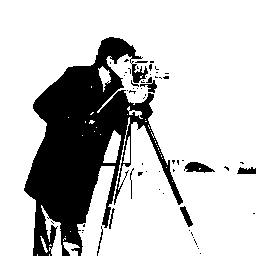

Threshold value: 100


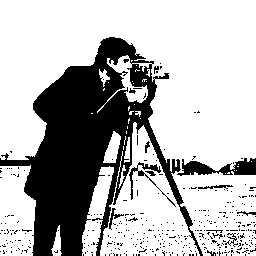

Threshold value: 150


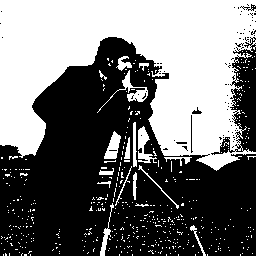

Threshold value: 200


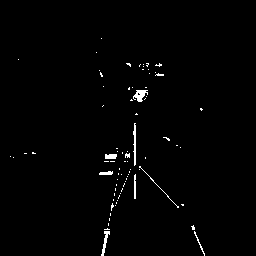

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(
        "cameraman.png was not found. Upload cameraman.png to the Colab session first."
    )

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(
        img, threshold_value, 255, cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image:


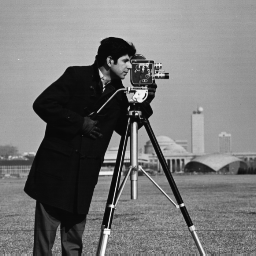

In [2]:
print("Original Image:")
cv2_imshow(img)

## Histograms

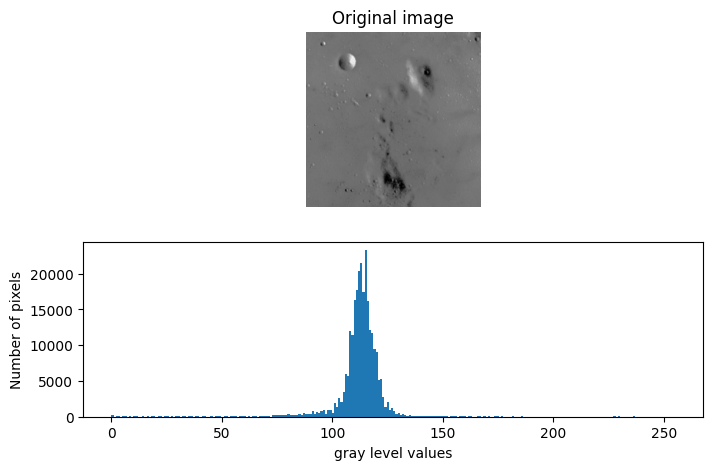

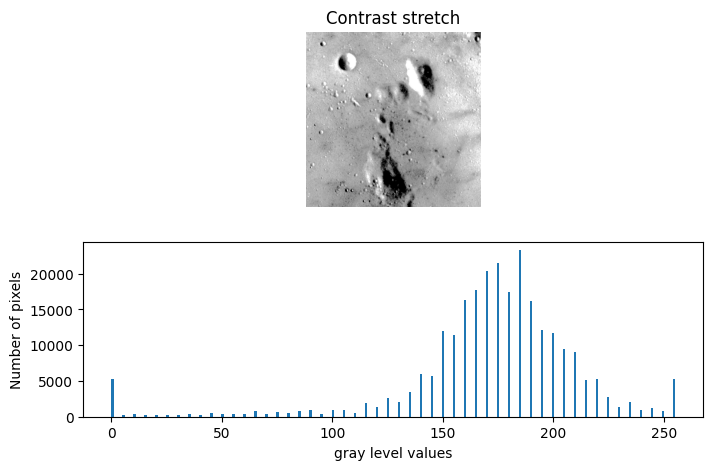

In [3]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


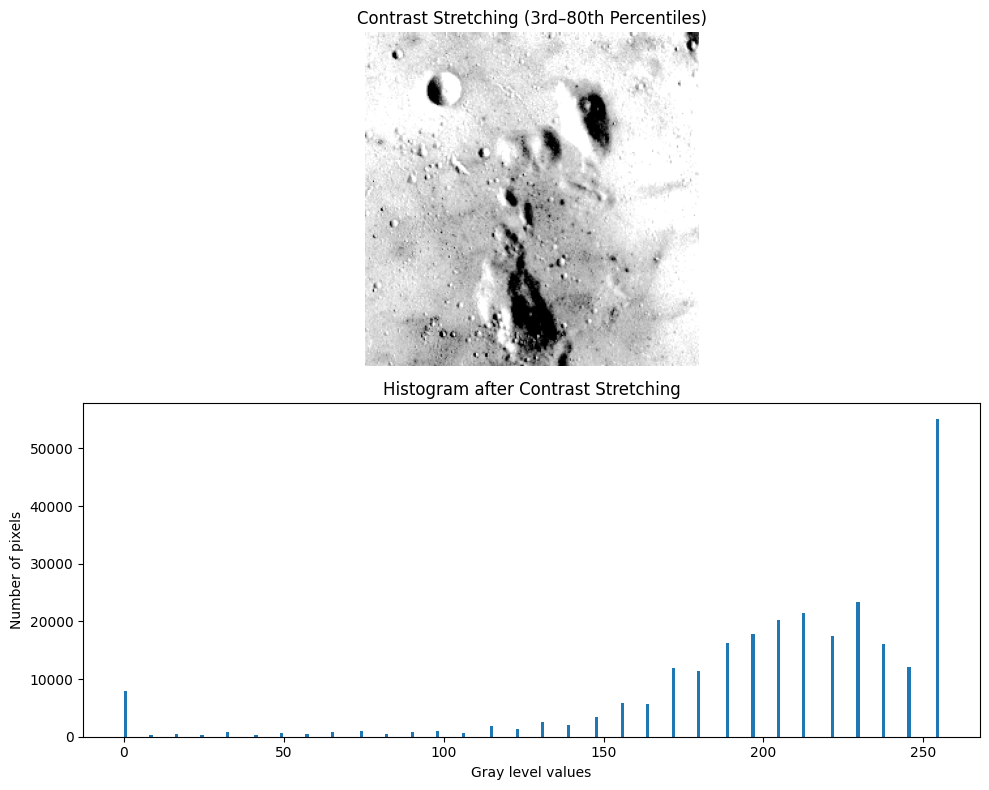

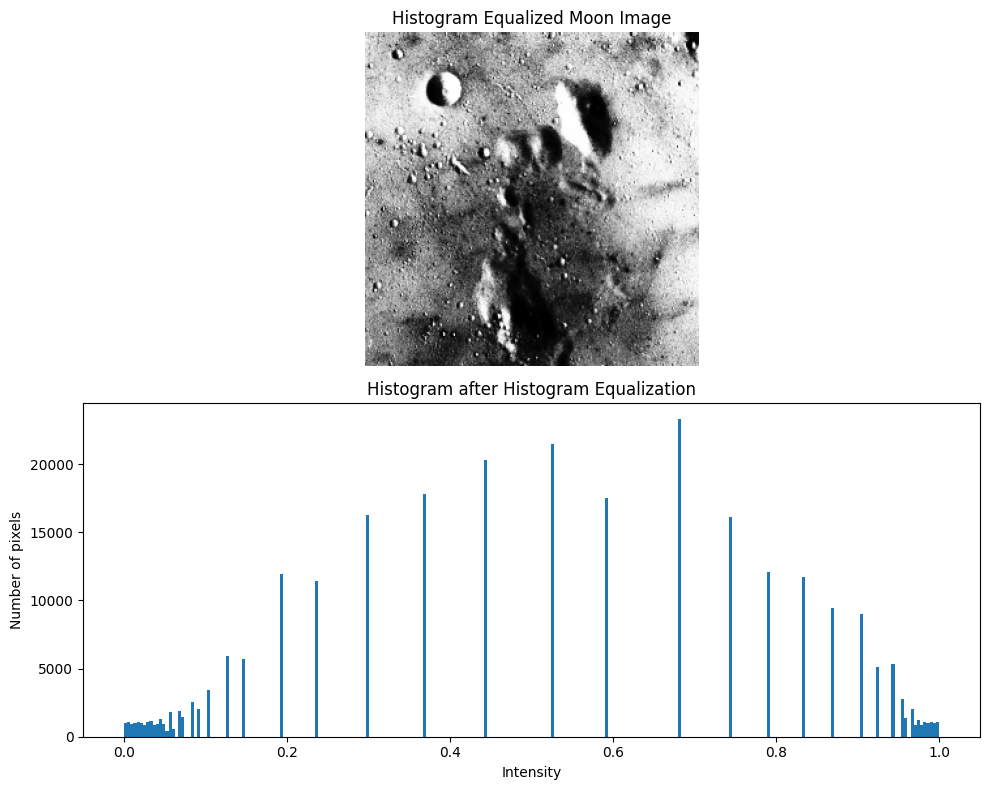

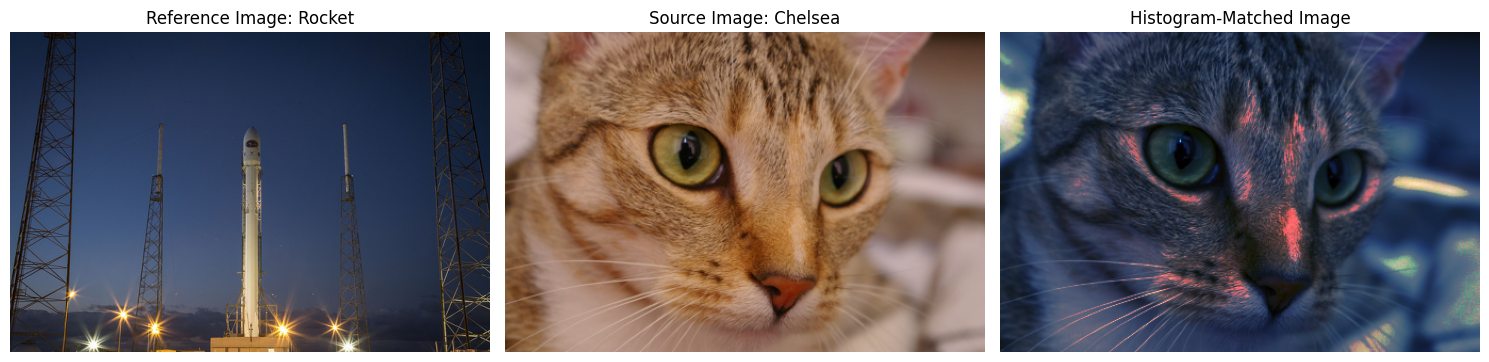

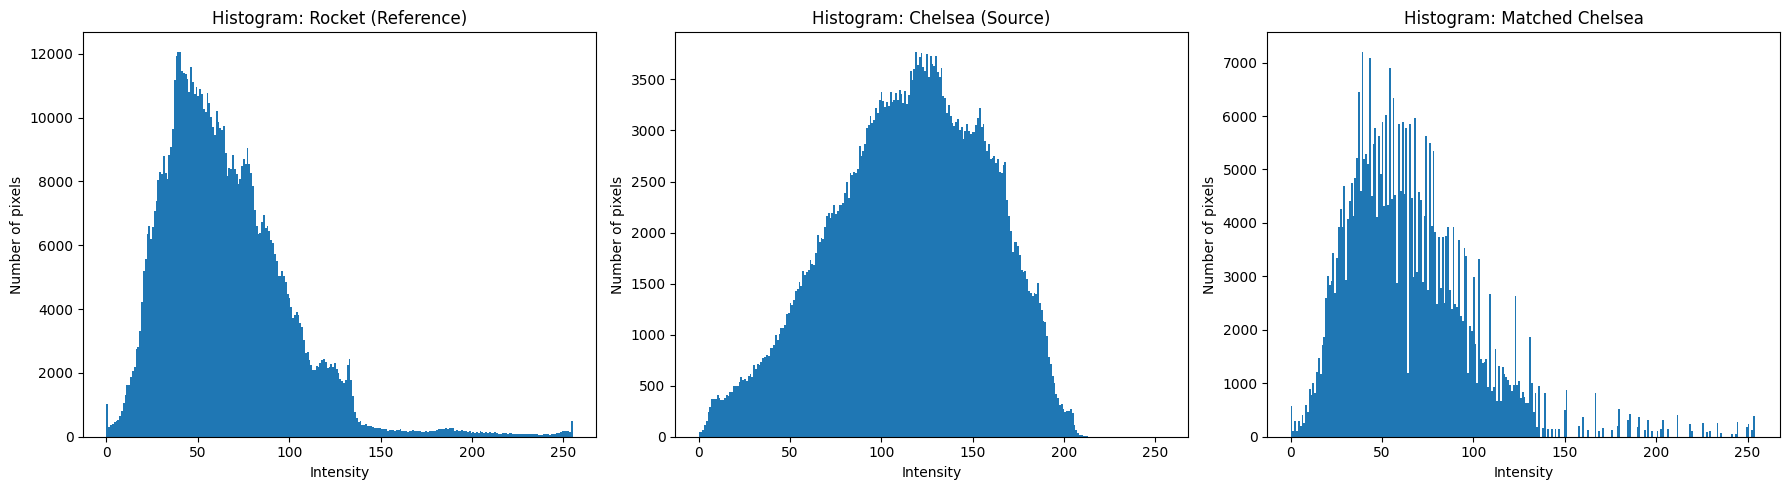

In [4]:
# ============================================
# Task 1: Contrast stretching using the 3rd and 80th percentiles
# ============================================

# Use the same moon image from Task 2
p3, p80 = np.percentile(img, (3, 80))

img_rescale_task1 = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img_rescale_task1, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretching (3rd–80th Percentiles)')

plt.subplot(2, 1, 2)
plt.hist(img_rescale_task1.ravel(), bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram after Contrast Stretching')

plt.tight_layout()
plt.show()


# ============================================
# Task 2: Histogram equalization
# ============================================

img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Moon Image')

plt.subplot(2, 1, 2)
plt.hist(img_equalized.ravel(), bins=256, range=(0, 1))
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')
plt.title('Histogram after Histogram Equalization')

plt.tight_layout()
plt.show()


# ============================================
# Task 3: Histogram matching
# Reference image: rocket
# Source image: chelsea
# ============================================

from skimage import data, exposure

# Load the images
reference = data.rocket()
source = data.chelsea()

# Match the histogram of the source image (chelsea)
# to the reference image (rocket)
matched = exposure.match_histograms(
    source,
    reference,
    channel_axis=-1
)

# Display the images
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

axes[0].imshow(reference)
axes[0].set_title('Reference Image: Rocket')
axes[0].axis('off')

axes[1].imshow(source)
axes[1].set_title('Source Image: Chelsea')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Histogram-Matched Image')
axes[2].axis('off')

plt.tight_layout()
plt.show()


# Display histograms for comparison
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Reference histogram
axes[0].hist(reference.ravel(), bins=256, range=(0, 255))
axes[0].set_title('Histogram: Rocket (Reference)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Number of pixels')

# Source histogram
axes[1].hist(source.ravel(), bins=256, range=(0, 255))
axes[1].set_title('Histogram: Chelsea (Source)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Number of pixels')

# Matched histogram
axes[2].hist(matched.ravel(), bins=256, range=(0, 255))
axes[2].set_title('Histogram: Matched Chelsea')
axes[2].set_xlabel('Intensity')
axes[2].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()